# Community detection

> **Note** to run this notebook you need to install the following package
>```bash
>conda activate CSS
>pip install scikit-network
>```

In [5]:
import warnings
warnings.filterwarnings('ignore')

from copy import copy
from time import time
from scipy.sparse.linalg import eigs, eigsh
from sklearn.metrics import adjusted_mutual_info_score as ami
import matplotlib.pyplot as plt
import sknetwork as skn

from src.CD import *

## Louvain algorithm

The Louvain algorithm is a greedy strategy to optimize the modularity on networks in order to find a community structure. The modularity is defined as

$$
\mathscr{Q}_A^{\rm Mod}(\mathbf{\ell}) = \frac{1}{2|\mathcal{E}|}\sum_{i,j\in\mathcal{V}}\left(A_{ij} - \frac{d_id_j}{2|\mathcal{E}}\right)\delta(\ell_i,\ell_j).
$$

This method does not require any prior knowledge of the input graph and it also outputs the number of communities. In many cases, however, the inferred node partition correspond to one of the many local minima of the modularity cost function: these local minima are many, hardly distinguishable in terms of modularity and uncorrelated with one-another. Moreover, the Louvain algorithm can find high modularity partitions also in completely random networks: keep this in mind when you are using it! 


### Modularity maximization on a random graph

In [6]:
n = 30000   # number of nodes
c = 5     # expected average degree

A = ErdosRenyi(n, c)

t0 = time()
louvain = skn.clustering.Louvain()
label = louvain.fit_predict(A)
k = len(np.unique(label))
print(f'Computation time: {time() - t0}')
print(f'Estimated number of classes = {k}')
print(f'Modularity = {ComputeModularity(A, label)}')

Computation time: 0.21334385871887207
Estimated number of classes = 269
Modularity = 0.433076697400344


Note that we achieve a very large modularity value with a large number of communities on a completely random network. As an exercise, see how the results change tuning the value of `c`. We now also test different runs of the algorithm on the **same** graph and measure the similarity between the partitions in terms od *adjusted mutual information*.


In [7]:
labels, ami_score, mod_values = [], [], []
n_runs = 100 # number of runs of modularity maximization

print('Computing the partitions')
for t in range(n_runs):
    print("Progress: [%-25s] %d%%" % ('='*(int((t+1)  /n_runs*25)-1) + '>', (t+1)/(n_runs)*100), end = '\r')
    louvain = skn.clustering.Louvain(shuffle_nodes = True) 
    labels.append(louvain.fit_predict(A))
    mod_values.append(ComputeModularity(A, labels[-1]))

# sample 100 random pairs
idx1, idx2 = np.random.choice(np.arange(n_runs), (100,2)).T

print('\n Comparing the partitions')
for counter, (i, j) in enumerate(zip(idx1, idx2)):
    print("Progress: [%-25s] %d%%" % ('='*(int((counter+1)  /len(idx1)*25)-1) + '>', (counter+1)/(len(idx1))*100), end = '\r')
    if i != j:
        ami_score.append(ami(labels[i], labels[j]))

Computing the partitions
Progress: [========================>] 100%
 Comparing the partitions


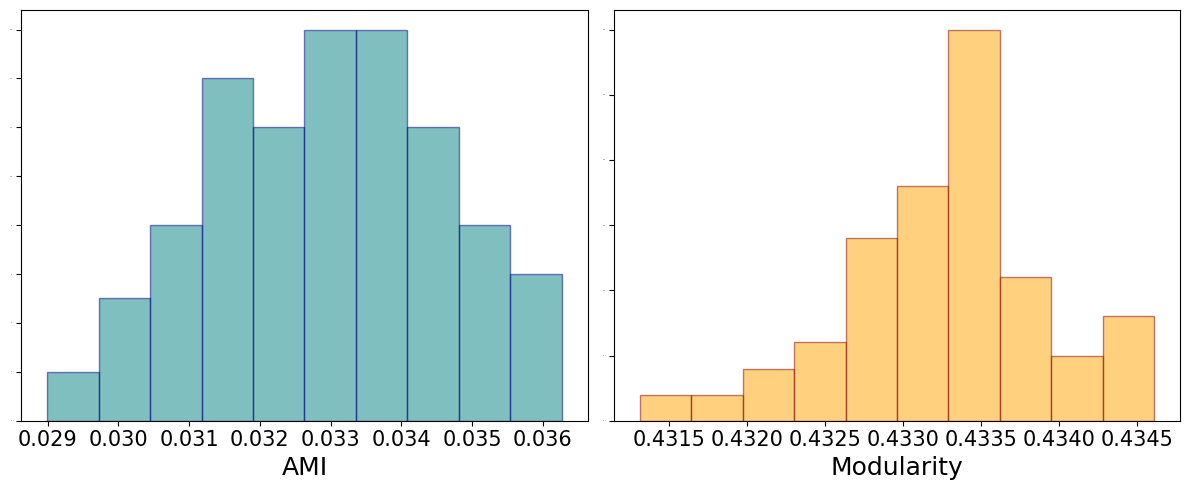

In [8]:
fig, ax = plt.subplots(1, 2, figsize = (12,5))

ax[0].hist(ami_score, color = 'teal', edgecolor = 'navy', alpha = 0.5)
ax[0].set_xlabel('AMI', fontsize = 18)
ax[0].tick_params(axis='x', which='major', labelsize=15)
ax[0].tick_params(axis='y', which='major', labelsize=0)

ax[1].hist(mod_values, color = 'orange', edgecolor = 'maroon', alpha = 0.5)
ax[1].set_xlabel('Modularity', fontsize = 18)
ax[1].tick_params(axis='x', which='major', labelsize=15)
ax[1].tick_params(axis='y', which='major', labelsize=0)

plt.tight_layout()
plt.show();

## Modularity maximization on a graph with communities

In the previous section we considered a corner case in which there was absolutely no structure in the graph. The limitations associated with Louvain, however, are still observed in the presence of a community structure but are alleviated as the communities are more and more apart. We generate a graph from the *Stochastic block model* with $k=2$ communities so that

$$
\mathbb{P}(A_{ij}=1) = \begin{cases} \frac{c_{\rm in}}{n} \quad{\rm if~} \ell_i = \ell_j \\
                                    \frac{c_{\rm out}}{n} \quad{\rm else}
                        \end{cases}
$$

> **EXERCISE**: see how the result varies in terms of estimated number of communities, ami score and modularity by changing the ratio $\Gamma = c_{\rm in}/c_{\rm out}$.

In [10]:
k = 2                            # number of communities
n = 30000   
α = 2.5                            # ratio c_in/c_out (the larger is alpha, the simpler the problem)
c = 10                           # expected average degree
c_in, c_out = 2*c*α/(1+α), 2*c/(1+α)  # connections parameters
C = np.ones((k,k))*c_out + np.diag(np.ones(k))*(c_in - c_out) 
c = (c_in + (k-1)*c_out)/k 
print(f'αa = {(c - c_out)/np.sqrt(c)}')

label_gt = np.ones(n)
label_gt[:int(n/2)] = 0
label_gt = label_gt.astype(int) # label vector
A, label = DCSBM(C,c, label_gt, np.ones(n))

t0 = time()
louvain = skn.clustering.Louvain()
label = louvain.fit_predict(A)
k = len(np.unique(label))
print(f'Computation time: {time() - t0}')
print(f'Estimated number of classes = {k}')
print(f'Modularity = {ComputeModularity(A, label)}')
print(f'AMI with ground truth partition', {ami(label, label_gt)})

αa = 1.3552618543578767
Computation time: 0.383347749710083
Estimated number of classes = 20
Modularity = 0.2589606618680507
AMI with ground truth partition {np.float64(0.0002430090795348948)}


## Bayesian inference

In the Bayesian framework, we consider community detection as an inference problem in which the labels have to be estimated from the adjacency matrix, which is a realization of a random variable.

$$
\mathbb{P}(\mathbf{\ell}|A) \propto \mathbb{P}(A|\mathbf{\ell})
$$

A first method is to maximize the the posterior distribution, or, equivalently, minimize the description length. Here we pick a smaller value of $n$ because these algorithms are slower.


> **NOTE**: these codes won't run in the current environmnent as you need to use `graph-tool`. If you want to use it, follow the instructions from the [official page](https://graph-tool.skewed.de/)

In [ ]:
from graph_tool import *
import graph_tool.all as gt

In [8]:
k = 2                            # number of communities
n = 3000   
Γ = 4                            # ratio c_in/c_out (the larger is alpha, the simpler the problem)
c = 10                           # expected average degree
c_in, c_out = 2*c*Γ/(1+Γ), 2*c/(1+Γ)  # connections parameters
C = np.ones((k,k))*c_out + np.diag(np.ones(k))*(c_in - c_out) 
c = (c_in + (k-1)*c_out)/k 
print(f'α = {(c - c_out)/np.sqrt(c)}')

label_gt = np.ones(n)
label_gt[:int(n/2)] = 0
label_gt = label_gt.astype(int) # label vector
A, label = DCSBM(C,c, label_gt, np.ones(n))

α = 1.8973665961010275


In [9]:
g = gt.Graph(directed=False)
g.add_edge_list(np.transpose(A.nonzero()))
t0 = time()
state = gt.minimize_blockmodel_dl(g, multilevel_mcmc_args=dict(B_max = 10))
label = np.array([state.get_blocks()[i] for i in range(n)])
print(f'Computation time: {time() - t0}')
print(f'Modularity = {ComputeModularity(A, label)}')
print(f'AMI with ground truth partition', {ami(label, label_gt)})

Computation time: 10.817868947982788
Modularity = 0.2777623274533254
AMI with ground truth partition {0.33976044084635443}


Instead of maximizing the posterior, we can sample from it. It takes longer, but it also potentially gives access to estimating the full marginals.

In [10]:
n_iter = 1000
t0 = time()

for i in range(n_iter): # this should be sufficiently large
    print("Progress: [%-25s] %d%%" % ('='*(int((i+1)/n_iter*25)-1) + '>', (i+1)/n_iter*100), end = '\r')
    state.gibbs_sweep(niter=10, allow_new_group = False)

label = np.array([state.get_blocks()[i] for i in range(n)])
print(f'Computation time: {time() - t0}')
print(f'Modularity = {ComputeModularity(A, label)}')
print(f'AMI with ground truth partition', {ami(label, label_gt)})

Computation time: 211.1382110118866>] 100%
Modularity = 0.16512517213321928
AMI with ground truth partition {0.3461689657279911}
